## Project 4: Insight Discovery through EDA

In [20]:
# Extract insights that matter

# Identify key trends, risks, & opportunities

# Perform detailed EDA on a real dataset

# Translate findings into business language

In [21]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")
print(f"Loaded {len(df):,} titles.")
df.head(3)

Loaded 8,807 titles.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## Extract Core Metrics

In [22]:
# Content distribution
content_split = df['type'].value_counts(normalize=True) * 100

# Top country & genre concentration
top_country = df['country'].dropna().str.split(', ').explode().value_counts().head(1)
top_genre = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(1)

# Display key numbers
print(f"Movies: {content_split.get('Movie', 0):.1f}% | TV Shows: {content_split.get('TV Show', 0):.1f}%")
print(f"Top Country: {top_country.index[0]} ({top_country.values[0]} titles)")
print(f"Top Genre: {top_genre.index[0]} ({top_genre.values[0]} titles)")

Movies: 69.6% | TV Shows: 30.4%
Top Country: United States (3689 titles)
Top Genre: International Movies (2752 titles)


##  Business Insights

In [23]:
movie_pct = round(content_split.get('Movie', 0), 1)
tv_pct = round(content_split.get('TV Show', 0), 1)
top_c_name = top_country.index[0]

print("EXECUTIVE EDA INSIGHTS")
print(f"1. TREND: Catalog favors Movies ({movie_pct}%) over TV Shows ({tv_pct}%).")
print(f"2. RISK: High content concentration in {top_c_name}, creating licensing dependency.")
print(f"3. OPPORTUNITY: Expand localized original content in emerging international regions to boost global subscriber retention.")

EXECUTIVE EDA INSIGHTS
1. TREND: Catalog favors Movies (69.6%) over TV Shows (30.4%).
2. RISK: High content concentration in United States, creating licensing dependency.
3. OPPORTUNITY: Expand localized original content in emerging international regions to boost global subscriber retention.


## Identifying Key Trends

In [24]:
type_split = df['type'].value_counts(normalize=True) * 100

latest_content = df[df['release_year'] >= 2015]['type'].value_counts()

print("KEY TRENDS")
print(f"- Catalog Ratio: {type_split.get('Movie', 0):.1f}% Movies vs {type_split.get('TV Show', 0):.1f}% TV Shows")
print(f"- Recent Content Additions (2015+): {latest_content.get('Movie', 0):,} Movies, {latest_content.get('TV Show', 0):,} TV Shows")

KEY TRENDS
- Catalog Ratio: 69.6% Movies vs 30.4% TV Shows
- Recent Content Additions (2015+): 4,017 Movies, 2,199 TV Shows


## Identifying Key Risks

In [25]:
top_countries = df['country'].dropna().str.split(', ').explode().value_counts()
top_1_share = (top_countries.iloc[0] / len(df)) * 100

missing_director_pct = (df['director'].isnull().sum() / len(df)) * 100

print("KEY RISKS")
print(f"- Market Concentration Risk: {top_countries.index[0]} accounts for {top_1_share:.1f}% of all listed titles.")
print(f"- Metadata Risk: {missing_director_pct:.1f}% of catalog entries are missing director information.")

KEY RISKS
- Market Concentration Risk: United States accounts for 41.9% of all listed titles.
- Metadata Risk: 29.9% of catalog entries are missing director information.


## identifying Key Opportunities

In [26]:
top_genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(3)

top_intl_markets = top_countries.iloc[1:4]

print("KEY OPPORTUNITIES")
print("- Top Genre Demand Drivers:")
for genre, count in top_genres.items():
    print(f"  * {genre}: {count:,} titles")

print("\n- High-Growth International Markets to Target:")
for country, count in top_intl_markets.items():
    print(f"  * {country}: {count:,} titles")

KEY OPPORTUNITIES
- Top Genre Demand Drivers:
  * International Movies: 2,752 titles
  * Dramas: 2,427 titles
  * Comedies: 1,674 titles

- High-Growth International Markets to Target:
  * India: 1,046 titles
  * United Kingdom: 804 titles
  * Canada: 445 titles


## EDA

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [28]:
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("netflix_titles.csv")

df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

print(f"Dataset Dimensions: {df.shape[0]:,} rows | {df.shape[1]} columns\n")
print(df.info())

Dataset Dimensions: 8,807 rows | 14 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year_added    8797 non-null   float64       
 13  month_added   8797 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1),

## Content Composition (Pie Chart & Count Plot)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10620\1098356399.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='Reds_r', ax=axes[1])


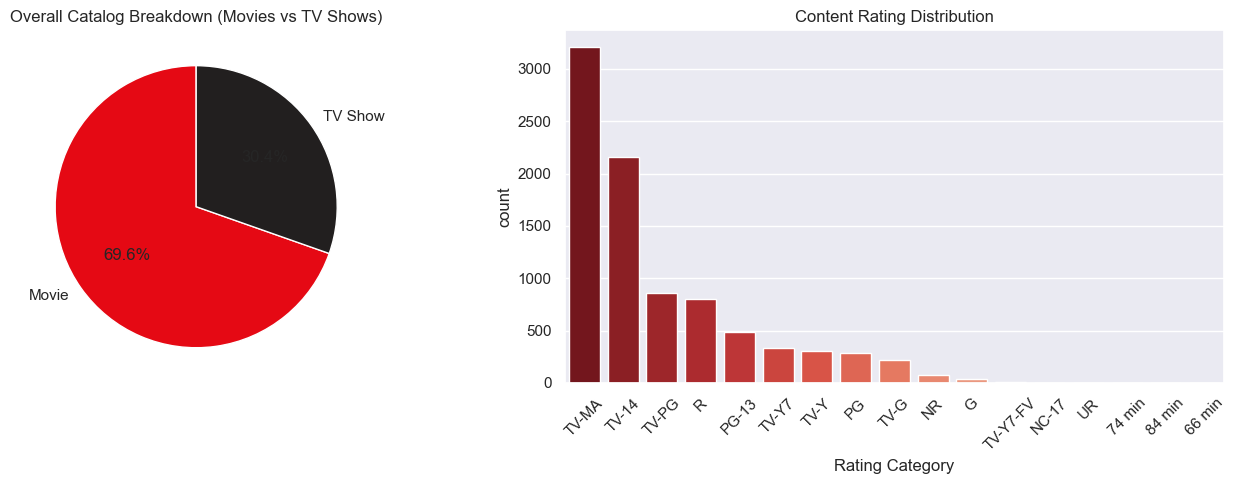

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df['type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#E50914', '#221F1F'], startangle=90)
axes[0].set_title('Overall Catalog Breakdown (Movies vs TV Shows)')

sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Content Rating Distribution')
axes[1].set_xlabel('Rating Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Time-Series Trends (Line & Area Chart)

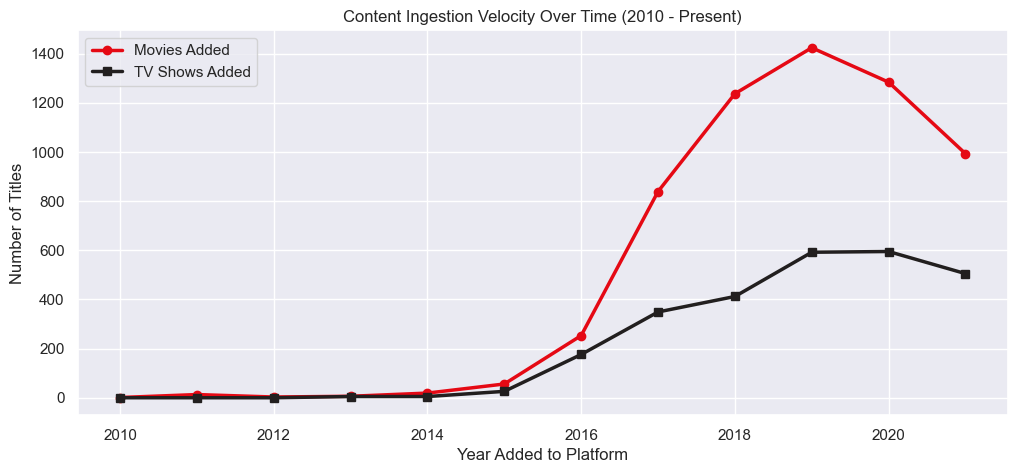

In [30]:
plt.figure(figsize=(12, 5))

yearly_trend = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_trend = yearly_trend[yearly_trend.index >= 2010]

plt.plot(yearly_trend.index, yearly_trend['Movie'], marker='o', linewidth=2.5, color='#E50914', label='Movies Added')
plt.plot(yearly_trend.index, yearly_trend['TV Show'], marker='s', linewidth=2.5, color='#221F1F', label='TV Shows Added')

plt.title('Content Ingestion Velocity Over Time (2010 - Present)')
plt.xlabel('Year Added to Platform')
plt.ylabel('Number of Titles')
plt.legend()
plt.show()

## Top Producing Nations & Genre Frequency (Horizontal Bar Maps)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_10620\4257917476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r', ax=axes[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10620\4257917476.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='dark:#E50914_r', ax=axes[1])


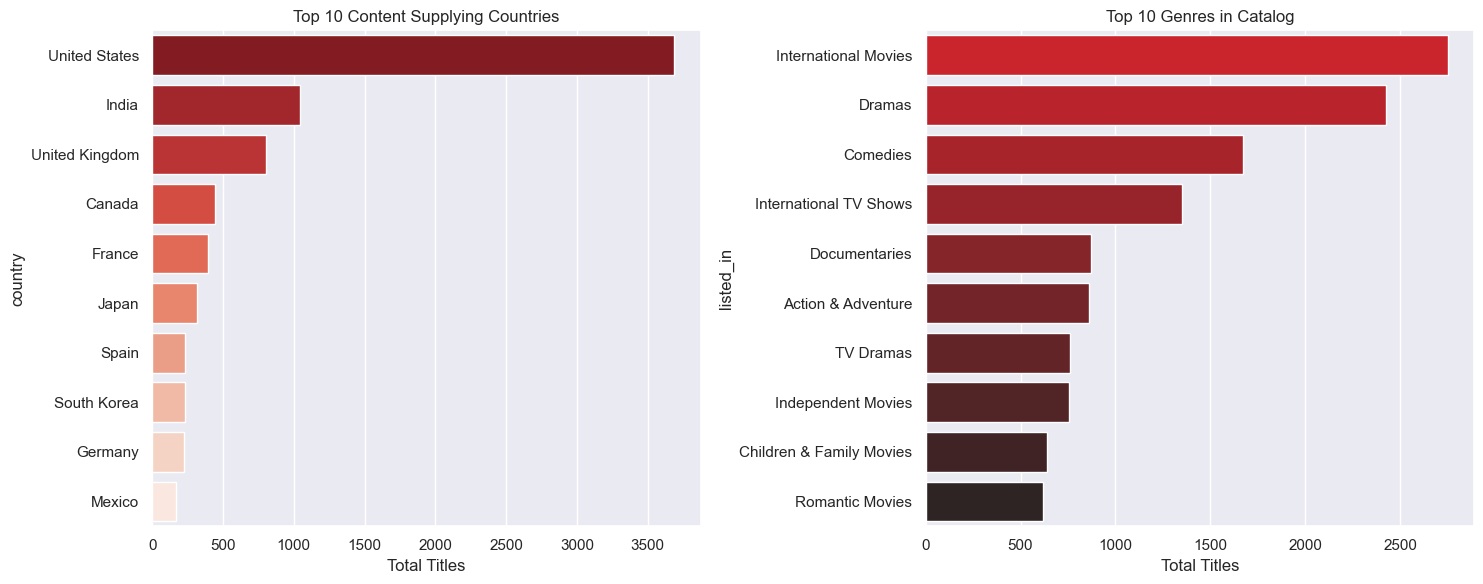

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_countries = df['country'].dropna().str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Content Supplying Countries')
axes[0].set_xlabel('Total Titles')

top_genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='dark:#E50914_r', ax=axes[1])
axes[1].set_title('Top 10 Genres in Catalog')
axes[1].set_xlabel('Total Titles')

plt.tight_layout()
plt.show()

## Duration Analysis (Distribution & Box Plots)

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10620\937824177.py:4: SyntaxWarning: invalid escape sequence '\d'
  movies_df['duration_min'] = movies_df['duration'].str.extract('(\d+)').astype(float)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10620\937824177.py:11: SyntaxWarning: invalid escape sequence '\d'
  tv_df['seasons'] = tv_df['duration'].str.extract('(\d+)').astype(float)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_10620\937824177.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tv_df, x='seasons', palette='Reds_r', ax=axes[1])


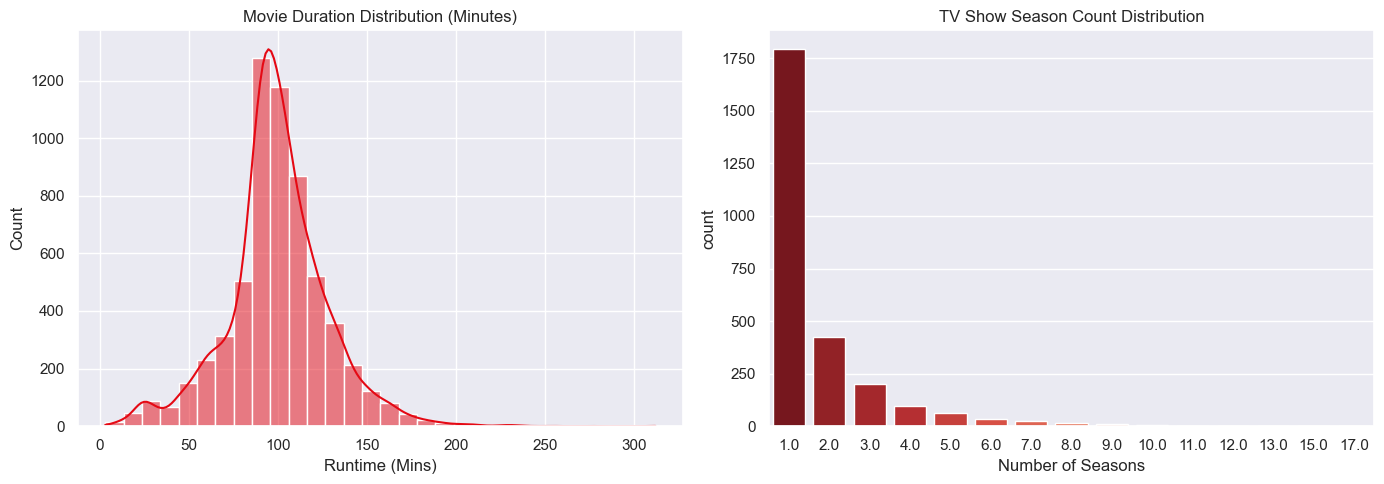

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.extract('(\d+)').astype(float)

sns.histplot(movies_df['duration_min'].dropna(), kde=True, color='#E50914', bins=30, ax=axes[0])
axes[0].set_title('Movie Duration Distribution (Minutes)')
axes[0].set_xlabel('Runtime (Mins)')

tv_df = df[df['type'] == 'TV Show'].copy()
tv_df['seasons'] = tv_df['duration'].str.extract('(\d+)').astype(float)

sns.countplot(data=tv_df, x='seasons', palette='Reds_r', ax=axes[1])
axes[1].set_title('TV Show Season Count Distribution')
axes[1].set_xlabel('Number of Seasons')

plt.tight_layout()
plt.show()

## Bivariate Correlation Map (Heatmap)

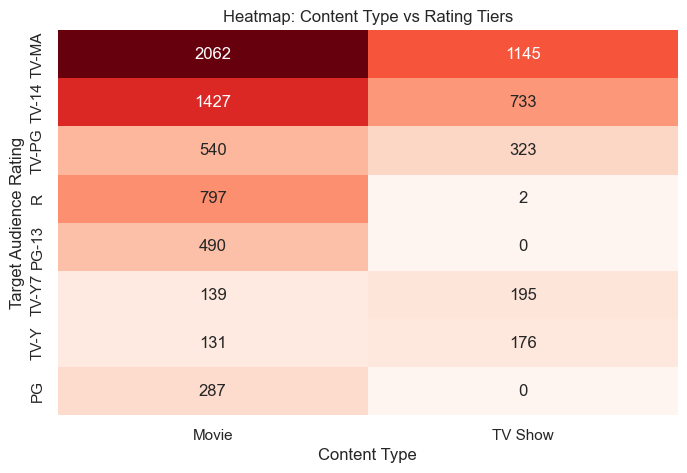

In [33]:
plt.figure(figsize=(8, 5))

cross_tab = pd.crosstab(df['rating'], df['type'])
top_ratings = df['rating'].value_counts().head(8).index
cross_tab_filtered = cross_tab.loc[top_ratings]

sns.heatmap(cross_tab_filtered, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Heatmap: Content Type vs Rating Tiers')
plt.xlabel('Content Type')
plt.ylabel('Target Audience Rating')
plt.show()

## Translate findings into business language

Calculating Key Business Metrics

In [34]:
# Compute core KPI percentages
total_titles = len(df)
type_counts = df['type'].value_counts()
movie_pct = round((type_counts.get('Movie', 0) / total_titles) * 100, 1)
tv_pct = round((type_counts.get('TV Show', 0) / total_titles) * 100, 1)

# Geographic concentration metric
top_country = df['country'].dropna().str.split(', ').explode().value_counts()
top_country_name = top_country.index[0]
top_country_pct = round((top_country.iloc[0] / total_titles) * 100, 1)

# Audience rating classification
tv_ma_count = len(df[df['rating'] == 'TV-MA'])
tv_ma_pct = round((tv_ma_count / total_titles) * 100, 1)

print("Key metrics computed successfully.")

Key metrics computed successfully.


## Translate Findings into Strategic Business Pillars

In [36]:
print("BUSINESS INSIGHTS")
print(f"1. TREND: Catalog is {movie_pct}% movies vs {tv_pct}% TV shows. Need more TV series for repeat retention.")
print(f"2. RISK: {top_country_name} holds {top_country_pct}% of content. High vendor dependency.")
print(f"3. OPPORTUNITY: {tv_ma_pct}% is TV-MA. Expanding PG/Family titles can unlock household growth.")

=== BUSINESS INSIGHTS ===
1. TREND: Catalog is 69.6% movies vs 30.4% TV shows. Need more TV series for repeat retention.
2. RISK: United States holds 41.9% of content. High vendor dependency.
3. OPPORTUNITY: 36.4% is TV-MA. Expanding PG/Family titles can unlock household growth.


In [37]:
pd.DataFrame({
    'Area': ['Retention', 'Risk', 'Growth'],
    'Metric': [f'{movie_pct}% Movies', f'{top_country_pct}% {top_country_name}', f'{tv_ma_pct}% TV-MA'],
    'Action': ['Fund more multi-season series', 'Diversify global content suppliers', 'Build out family/PG catalog']
})

,Area,Metric,Action
0,Retention,69.6% Movies,Fund more multi-season series
1,Risk,41.9% United States,Diversify global content suppliers
2,Growth,36.4% TV-MA,Build out family/PG catalog
